<a href="https://colab.research.google.com/github/lightcode01-oss/IYB_INTERNSHIP/blob/main/Day_09_Decision_Tree_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DAY 09 — Decision Tree Classification Model

## YBI Foundation — Python, AI & Data Science Internship

### Objective

The objective of Day 09 is to train a Decision Tree classification model
for predicting student performance categories.

The Decision Tree model will be evaluated using the same methodology used
for the Day 08 Logistic Regression baseline.

### Today's Work

- Load the dataset independently.
- Recreate the project target.
- Prevent target leakage.
- Prepare the same feature groups.
- Perform a stratified train-test split.
- Build the preprocessing pipeline.
- Train a Decision Tree classifier.
- Generate predictions.
- Evaluate the model.
- Analyze the confusion matrix.
- Compare Decision Tree with Logistic Regression.
- Record the results.

No hyperparameter tuning will be performed today.

In [ ]:
!pip -q install ucimlrepo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
student_performance = fetch_ucirepo(id=320)

X = student_performance.data.features
y_original = student_performance.data.targets

df = X.copy()
df["G3"] = y_original["G3"]

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (649, 31)


In [ ]:
def performance_category(grade):
    if grade < 10:
        return "Low"
    elif grade < 15:
        return "Medium"
    else:
        return "High"

df["performance_category"] = df["G3"].apply(
    performance_category
)

print(df["performance_category"].value_counts())

performance_category
Medium    418
High      131
Low       100
Name: count, dtype: int64


In [ ]:
target = "performance_category"

X = df.drop(columns=[target])
y = df[target]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Feature shape: (649, 31)
Target shape: (649,)

Target distribution:
performance_category
Medium    418
High      131
Low       100
Name: count, dtype: int64


In [ ]:
X_model = X.drop(columns=["G3"])

print("G3 present in model features:", "G3" in X_model.columns)
print("Final model feature count:", X_model.shape[1])

G3 present in model features: False
Final model feature count: 30


In [ ]:
numerical_features = [
    "age",
    "absences"
]

ordinal_features = [
    "Medu",
    "Fedu",
    "traveltime",
    "studytime",
    "failures",
    "famrel",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health"
]

binary_features = [
    "school",
    "sex",
    "address",
    "famsize",
    "Pstatus",
    "schoolsup",
    "famsup",
    "paid",
    "activities",
    "nursery",
    "higher",
    "internet",
    "romantic"
]

nominal_features = [
    "Mjob",
    "Fjob",
    "reason",
    "guardian"
]

categorical_features = (
    binary_features +
    nominal_features
)

print("Numerical features:", len(numerical_features))
print("Ordinal features:", len(ordinal_features))
print("Categorical features:", len(categorical_features))

Numerical features: 2
Ordinal features: 11
Categorical features: 17


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 519
Testing samples: 130


In [ ]:
categorical_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_encoder,
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features + ordinal_features
        )
    ],
    remainder="drop"
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [ ]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

print("Decision Tree classifier created successfully.")

Decision Tree classifier created successfully.


In [ ]:
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", decision_tree)
    ]
)

print("Decision Tree pipeline created successfully.")

Decision Tree pipeline created successfully.


In [ ]:
decision_tree_pipeline.fit(
    X_train,
    y_train
)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [ ]:
y_pred = decision_tree_pipeline.predict(X_test)

print("Predictions generated successfully.")

print("\nFirst 20 predictions:")
print(y_pred[:20])

Predictions generated successfully.

First 20 predictions:
['Medium' 'Low' 'High' 'Medium' 'Low' 'Medium' 'Low' 'Medium' 'Medium'
 'Low' 'Medium' 'Medium' 'High' 'Low' 'Medium' 'Medium' 'Medium' 'High'
 'Medium' 'High']


In [ ]:
prediction_comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

prediction_comparison.head(20)

,Actual,Predicted
0,Medium,Medium
1,Low,Low
2,Medium,High
3,Low,Medium
4,Medium,Low
5,Medium,Medium
6,High,Low
7,Medium,Medium
8,Medium,Medium
9,Low,Low


In [ ]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Decision Tree Accuracy:", round(accuracy, 4))
print("Decision Tree Accuracy (%):", round(accuracy * 100, 2))

Decision Tree Accuracy: 0.5308
Decision Tree Accuracy (%): 53.08


In [ ]:
precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

print("Macro Precision:", round(precision, 4))

Macro Precision: 0.4468


In [ ]:
recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

print("Macro Recall:", round(recall, 4))

Macro Recall: 0.4639


In [ ]:
f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

print("Macro F1 Score:", round(f1, 4))

Macro F1 Score: 0.4509


In [ ]:
decision_tree_results = pd.DataFrame({
    "Model": ["Decision Tree"],
    "Accuracy": [accuracy],
    "Macro Precision": [precision],
    "Macro Recall": [recall],
    "Macro F1": [f1]
})

decision_tree_results

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Decision Tree,0.530769,0.446826,0.463919,0.450885


In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        labels=["Low", "Medium", "High"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

         Low       0.28      0.40      0.33        20
      Medium       0.68      0.61      0.64        84
        High       0.38      0.38      0.38        26

    accuracy                           0.53       130
   macro avg       0.45      0.46      0.45       130
weighted avg       0.56      0.53      0.54       130



In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Low", "Medium", "High"]
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 8 10  2]
 [19 51 14]
 [ 2 14 10]]


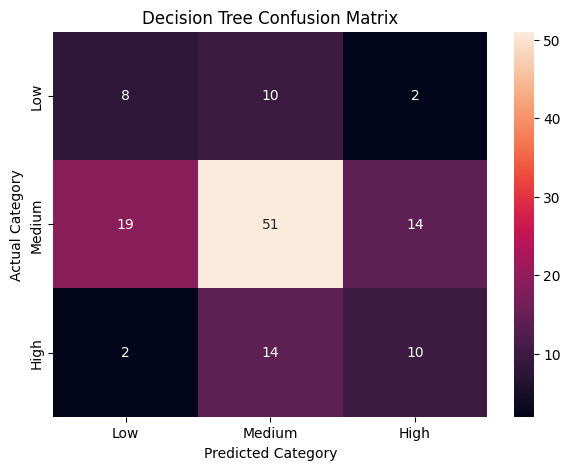

In [ ]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.show()

In [ ]:
y_train_pred = decision_tree_pipeline.predict(X_train)

train_accuracy = accuracy_score(
    y_train,
    y_train_pred
)

test_accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Training Accuracy:", round(train_accuracy, 4))
print("Testing Accuracy:", round(test_accuracy, 4))

Training Accuracy: 1.0
Testing Accuracy: 0.5308


In [ ]:
accuracy_gap = train_accuracy - test_accuracy

print("Training Accuracy:", round(train_accuracy, 4))
print("Testing Accuracy:", round(test_accuracy, 4))
print("Accuracy Gap:", round(accuracy_gap, 4))

Training Accuracy: 1.0
Testing Accuracy: 0.5308
Accuracy Gap: 0.4692


In [ ]:
print("Actual test distribution:")
print(y_test.value_counts())

print("\nPredicted distribution:")
print(pd.Series(y_pred).value_counts())

Actual test distribution:
performance_category
Medium    84
High      26
Low       20
Name: count, dtype: int64

Predicted distribution:
Medium    75
Low       29
High      26
Name: count, dtype: int64


In [ ]:
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", ColumnTransformer(
            transformers=[
                (
                    "categorical",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False
                    ),
                    categorical_features
                ),
                (
                    "numerical",
                    "passthrough",
                    numerical_features + ordinal_features
                )
            ],
            remainder="drop"
        )),
        ("classifier", logistic_model)
    ]
)

logistic_pipeline.fit(
    X_train,
    y_train
)

logistic_pred = logistic_pipeline.predict(X_test)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_pred
)

logistic_precision = precision_score(
    y_test,
    logistic_pred,
    average="macro",
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_pred,
    average="macro",
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    logistic_pred,
    average="macro",
    zero_division=0
)

print("Logistic Regression results calculated.")

Logistic Regression results calculated.


In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        logistic_accuracy,
        accuracy
    ],
    "Macro Precision": [
        logistic_precision,
        precision
    ],
    "Macro Recall": [
        logistic_recall,
        recall
    ],
    "Macro F1": [
        logistic_f1,
        f1
    ]
})

model_comparison

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.669231,0.599889,0.507631,0.510613
1,Decision Tree,0.530769,0.446826,0.463919,0.450885


In [ ]:
model_comparison_rounded = model_comparison.copy()

metric_columns = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1"
]

model_comparison_rounded[metric_columns] = (
    model_comparison_rounded[metric_columns].round(4)
)

model_comparison_rounded

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.6692,0.5999,0.5076,0.5106
1,Decision Tree,0.5308,0.4468,0.4639,0.4509


In [ ]:
best_model_index = model_comparison["Macro F1"].idxmax()

best_model = model_comparison.loc[
    best_model_index,
    "Model"
]

best_f1 = model_comparison.loc[
    best_model_index,
    "Macro F1"
]

print("Best model by Macro F1:", best_model)
print("Macro F1:", round(best_f1, 4))

Best model by Macro F1: Logistic Regression
Macro F1: 0.5106


<Figure size 900x500 with 0 Axes>

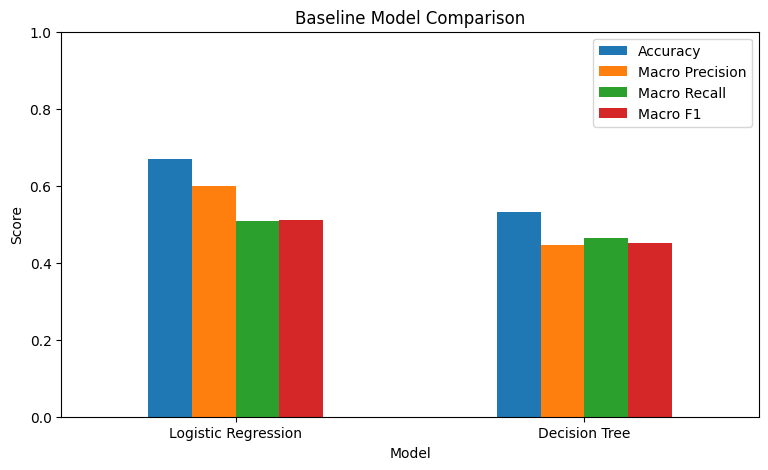

In [ ]:
plt.figure(figsize=(9, 5))

comparison_plot = model_comparison.set_index("Model")[
    ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"]
]

comparison_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Baseline Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [ ]:
model_comparison.to_csv(
    "day_09_model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


In [ ]:
print("=" * 60)
print("DAY 09 MODEL CHECK")
print("=" * 60)

print("Model tested:", "Decision Tree")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nDecision Tree Training Accuracy:",
      round(train_accuracy, 4))

print("Decision Tree Testing Accuracy:",
      round(test_accuracy, 4))

print("Decision Tree Macro Precision:",
      round(precision, 4))

print("Decision Tree Macro Recall:",
      round(recall, 4))

print("Decision Tree Macro F1:",
      round(f1, 4))

print("\nCurrent best model by Macro F1:",
      best_model)

print("\nG3 leakage removed:",
      "G3" not in X_model.columns)

print("\nDay 09 completed successfully.")

DAY 09 MODEL CHECK
Model tested: Decision Tree
Training samples: 519
Testing samples: 130

Decision Tree Training Accuracy: 1.0
Decision Tree Testing Accuracy: 0.5308
Decision Tree Macro Precision: 0.4468
Decision Tree Macro Recall: 0.4639
Decision Tree Macro F1: 0.4509

Current best model by Macro F1: Logistic Regression

G3 leakage removed: True

Day 09 completed successfully.


# Day 09 — Decision Tree Findings

## Model Selection

A Decision Tree Classifier was introduced as the second machine learning
algorithm for the project.

The model was selected because Decision Trees can capture non-linear
relationships and feature interactions that a linear model may not capture.

## Preprocessing

The same preprocessing strategy used in the previous days was integrated
with the Decision Tree through a Scikit-learn Pipeline.

This ensured that categorical encoding and model training were performed as
one reproducible workflow.

## Evaluation

The Decision Tree was evaluated using:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1 Score
- Classification Report
- Confusion Matrix

## Model Comparison

The Decision Tree results were compared with the Day 08 Logistic Regression
baseline using the same train-test split and evaluation metrics.

Macro F1 was used as an important comparison metric because the project has
three performance categories.

## Training and Testing Performance

Training and testing accuracy were compared to understand the initial
generalization behavior of the Decision Tree.

Decision Trees can potentially fit training data very closely, so the
training-testing difference will be monitored in later experiments.

## Target Leakage

The `G3` feature was excluded from the model because the target
`performance_category` is directly derived from `G3`.

Therefore, the model does not receive direct access to the variable used to
create the target.

## Conclusion

Day 09 established the Decision Tree as the second classification model and
created the first direct comparison between two machine learning algorithms.

Further algorithms and systematic evaluation will be performed before
selecting the final model.

# DAY 09 DEVELOPMENT LOG

## Work Completed

- Created an independent Day 09 notebook.
- Loaded the Student Performance dataset.
- Recreated the project target.
- Removed `G3` to prevent target leakage.
- Recreated the feature groups.
- Performed a stratified train-test split.
- Built the preprocessing pipeline.
- Created a Decision Tree Classifier.
- Integrated preprocessing and classification into one pipeline.
- Trained the Decision Tree model.
- Generated test predictions.
- Calculated accuracy.
- Calculated macro precision.
- Calculated macro recall.
- Calculated macro F1 score.
- Generated a classification report.
- Generated a confusion matrix.
- Compared training and testing accuracy.
- Compared Decision Tree with Logistic Regression.
- Created a model comparison table.
- Visualized model performance.
- Saved model comparison results.

## Key Learning

Different machine learning algorithms can learn patterns from the same
prepared dataset in different ways.

Decision Trees can model non-linear relationships and feature interactions,
while Logistic Regression provides a simpler linear baseline.

## Important Project Decision

The same dataset split, preprocessing procedure and evaluation metrics will
be maintained while testing future models.

This keeps model comparisons more consistent.

## Next Step

Day 10 will introduce another classification algorithm and continue building
the model comparison stage of the project.